# **Proyecto 3** | Implementación de Modelos de Regresión

### Link del Repositorio

* https://github.com/paulabaal12/PROY3-DM

### Integrantes del equipo
- [Mónica Salvatierra - 22249](https://github.com/alee2602)
- [Paula Barillas - 22764](https://github.com/paulabaal12)
- [Derek Arreaga - 22537](https://github.com/FabianKel) 
- [Juan Pablo Solís - 22102](https://github.com/JPS4321)

## Implementación de Modelos de Regresión

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
pd.options.display.max_columns = None

### Ejecución de Pipeline de preprocesamiento de datos

In [58]:
# Definición de datasets
df_customer_value = None
df_customer_value_scaled = None
# Ejecución de Pipeline
%run test.ipynb
#%run pipeline.ipynb


### Dataset a Utilizar: **df_customer_value_scaled**
1. ``customer_id``: ID del cliente
2. ``total_spent``: Monto total gastado por el cliente en su única compra.
3. ``order_size``: Cantidad de Productos por pedido
4. ``review_score``: Calificación promedio del pedido dado por el cliente (de 1 a 5).
5. ``customer_state``: Estado (región) del cliente codificado con LabelEncoder.
6. ``purchased_category_frequency``: Categoría de producto que predomina el pedido
7. ``highest_category_value``: Categoría del producto más caro del pedido
8. ``delivery_delay``: Días de retraso (o adelanto si es negativo) en la entrega del pedido.
9. ``payment_type``: Método de pago utilizado
10. ``payment_installments``: Número de cuotas o plazos en los que se pagó el pedido.
11. ``price_mean_per_order``: Promedio del precio de los productos comprados en el pedido.
12. ``freight_value``: Costo total del envío del pedido.


### **Matriz de correlación**

Top características correlacionadas con total_spent:
price_mean_per_order    0.910818
freight_value           0.487260
payment_installments    0.318325
order_size              0.187271
delivery_delay         -0.017317
review_score           -0.047706
Name: total_spent, dtype: float64


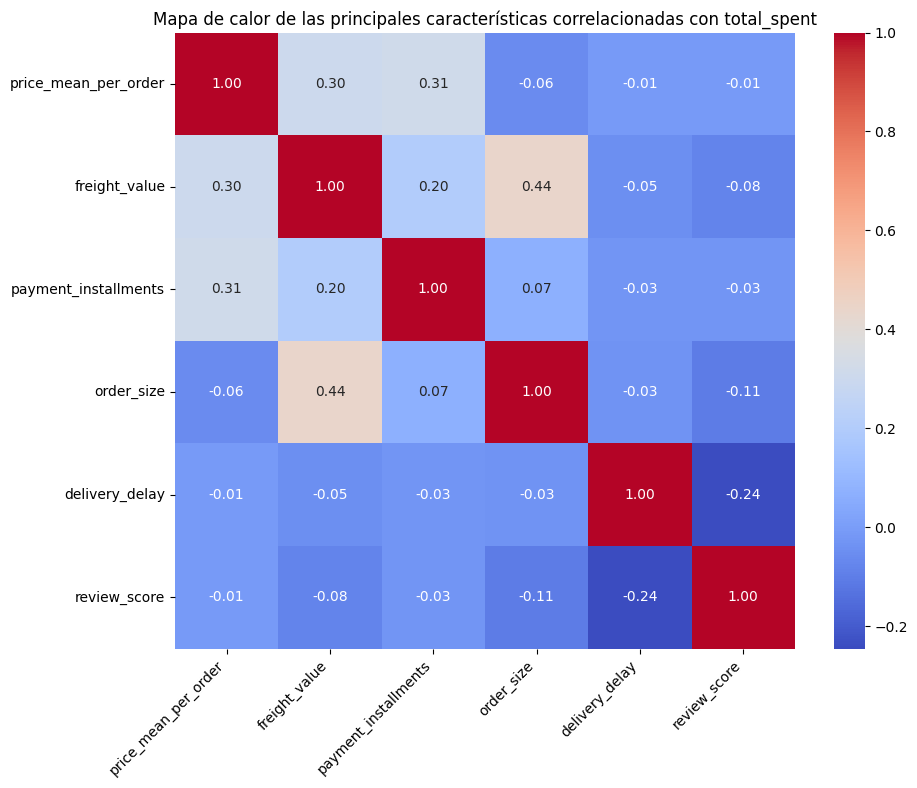

In [59]:

numeric_data = df_customer_value_scaled[['total_spent', 'order_size', 'review_score', 'delivery_delay', 'payment_installments', 'price_mean_per_order', 'freight_value']]
#Calcular la matriz de correlación
correlation_matrix = numeric_data.corr()

# Correlaciones con total_spent
total_spent_correlations = correlation_matrix['total_spent'].sort_values(ascending=False)

top_corr_features = total_spent_correlations.index[1:7]  

print("Top características correlacionadas con total_spent:")
print(total_spent_correlations[1:7])

# 5. Visualizar las correlaciones entre esas variables
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de las principales características correlacionadas con total_spent')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### **Definir conjuntos X y y**

In [60]:

# y = total_spent (posición 1)
y = df_customer_value_scaled.iloc[:, 1]

# X = todas las columnas de la posición 2 hasta la útlima
X = df_customer_value_scaled.iloc[:, 2:]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


Shape de X: (99992, 10)
Shape de y: (99992,)


In [61]:
df_customer_value_scaled.sort_values(by='highest_category_value', ascending=False)

,customer_unique_id,total_spent,order_size,review_score,customer_state,purchased_category_frequency,highest_category_value,delivery_delay,payment_type,payment_installments,price_mean_per_order,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,-0.551129,1.0,4.0,25,73,73,0.387246,5,-0.711356,-0.502180,-0.652334
23580,1856e7ddbf6567f246428dee7282b021,0.588966,2.0,1.0,19,63,73,-1.606633,2,2.598927,-0.283671,5.827893
99886,05253cc1e18f357919d8f21a65a3b604,-0.211068,1.0,5.0,10,73,73,-1.506939,2,0.392072,-0.204675,0.222093
99918,f6339afaeb5b5530e3500c5158f68422,-0.474949,1.0,5.0,25,73,73,-0.011530,2,0.759881,-0.444269,-0.379424
99919,888af42530e7523201a4326273a7b35c,-0.089937,3.0,4.0,25,73,73,-0.310611,3,-0.711356,-0.478788,0.688546
...,...,...,...,...,...,...,...,...,...,...,...,...
72511,33b9dba81a2e17209bce55d2f9969273,0.131655,4.0,3.0,10,0,0,-0.509999,2,2.598927,-0.484228,1.560653
55481,ded0f90b96bc30dfa105a41bbe658cdf,-0.225240,1.0,1.0,18,0,0,-0.011530,2,-0.711356,-0.244160,-0.260142
55433,d10f23d669c51e0d983ba80de4d327e8,-0.638503,1.0,5.0,25,0,0,0.486940,5,-0.711356,-0.620582,-0.507061
4269,af70cd6337ae27de089c616dad39bea0,-0.624828,1.0,1.0,10,0,0,-0.011530,2,-0.343547,-0.244160,-0.260142


### **División de conjuntos de entrenamiento y prueba**

In [62]:
from sklearn.model_selection import train_test_split

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,          
    y,          
    test_size=0.2,  
    random_state=16 
)

# Verificar dimensiones
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)


Shape de X_train: (79993, 10)
Shape de X_test: (19999, 10)
Shape de y_train: (79993,)
Shape de y_test: (19999,)


### Regresión Lineal Simple

#### Implementación

In [63]:
# code here


#### Métricas de Rendimiento

In [64]:
# code here

### Regresión Múltiple

#### Implementación

In [65]:
# code here

#### Métricas de Rendimiento

In [66]:
# code here

### Regresión Polinomial

#### Implementación

In [67]:
# code here

#### Métricas de Rendimiento

In [68]:
# code here

### Árboles de decisión

#### Implementación

In [69]:
# code here

#### Métricas de Rendimiento

In [70]:
# code here

### Random Forest

#### Implementación

In [71]:
#ode here

#### Métricas de Rendimiento

In [72]:
# code here

### SVR (Support Vector Regression)

#### Implementación

In [73]:
# code here

#### Métricas de Rendimiento

In [74]:
# code here